In [ ]:
# Convolution Operations from Scratch

In this notebook, we implement the fundamental operations behind Convolutional Neural Networks (CNNs) using NumPy only.

We will learn how convolution works, how output dimensions are computed, and how padding and stride affect the resulting feature maps.
No deep learning framework is used for the convolution implementation.

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data

In [99]:
image = np.array([
[3, 0, 1, 2, 7],
[1, 5, 8, 9, 3],
[2, 7, 2, 5, 1],
[0, 1, 3, 1, 7],
[4, 2, 1, 6, 2]])

kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]])

rgb_image = np.array([
    [[255, 0, 0],   [0, 255, 0],   [0, 0, 255]],   
    [[255, 255, 0], [0, 255, 255], [255, 0, 255]], 
    [[128, 128, 128],[255, 255, 255],[0, 0, 0]]   
], dtype=np.uint8)

print(rgb_image.shape)  
print(rgb_image)

print ("Shape de image :" , image.shape)
print ("Shape du kernel :" , kernel.shape)

(3, 3, 3)
[[[255   0   0]
  [  0 255   0]
  [  0   0 255]]

 [[255 255   0]
  [  0 255 255]
  [255   0 255]]

 [[128 128 128]
  [255 255 255]
  [  0   0   0]]]
Shape de image : (5, 5)
Shape du kernel : (3, 3)


In [100]:
def compute_output_size(input_size, filter_size, padding, stride):
    return ((input_size + 2 * padding - filter_size) // stride) + 1

In [101]:
test_cases = [
    (5, 3, 0, 1),
    (5, 3, 1, 1),
    (7, 3, 0, 2),
    (32, 5, 2, 1),
    (64, 5, 0, 2),
]

for input_size, filter_size, padding, stride in test_cases:
    output = compute_output_size(input_size, filter_size, padding, stride)
    print(
        f"Input={input_size}, Kernel={filter_size}, Padding={padding}, "
        f"Stride={stride} -> OUTPUT={output}"
    )

Input=5, Kernel=3, Padding=0, Stride=1 -> OUTPUT=3
Input=5, Kernel=3, Padding=1, Stride=1 -> OUTPUT=5
Input=7, Kernel=3, Padding=0, Stride=2 -> OUTPUT=3
Input=32, Kernel=5, Padding=2, Stride=1 -> OUTPUT=32
Input=64, Kernel=5, Padding=0, Stride=2 -> OUTPUT=30


In [102]:
def convolution2d(image, kernel, padding=0, stride=1 , mode = "constant"):
   
    if padding > 0:
        image = np.pad(image,((padding, padding), (padding, padding)),mode=mode)
        
    H, W = image.shape
    fH, fW = kernel.shape

    out_H = ((H - fH) // stride) + 1
    out_W = ((W - fW) // stride) + 1

    output = np.zeros((out_H, out_W))

    for i in range(out_H):
        for j in range(out_W):
            region = image[i*stride:i*stride+fH,j*stride:j*stride+fW]
            output[i, j] = np.sum(region * kernel)

    return output

In [103]:
image = np.array([
    [3,0,1,2,7],
    [1,5,8,9,3],
    [2,7,2,5,1],
    [0,1,3,1,7],
    [4,2,1,6,2]
])

kernel = np.array([
    [1,0,1],
    [0,1,0],
    [1,0,1]
])

feature_map = convolution2d(image, kernel)

print(feature_map)

[[13. 22. 20.]
 [19. 18. 26.]
 [10. 23.  7.]]


In [105]:
def convolution_rgb(image, filters, padding=0, stride=1):
    # image : (H, W, C)
    # filters : (num_filters, fH, fW, fC)
    
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding), (0, 0)), mode="constant")
    
    H, W, C = image.shape
    num_filters, fH, fW, fC = filters.shape
    
    assert C == fC, "Kernel depth must match image depth."
    
    out_H = ((H - fH) // stride) + 1
    out_W = ((W - fW) // stride) + 1
    
    # Sortie : (out_H, out_W, num_filters)
    output = np.zeros((out_H, out_W, num_filters))
    
    for n in range(num_filters): 
        kernel = filters[n]       
        for i in range(out_H):
            for j in range(out_W):
                result = 0
                for c in range(C): 
                    region = image[
                        i*stride:i*stride+fH,
                        j*stride:j*stride+fW,
                        c
                    ]
                    kernel_slice = kernel[:, :, c]
                    result += np.sum(region * kernel_slice)
                output[i, j, n] = result
    
    return output


In [106]:
def convolution_multiple_filters(image, filters, padding=0, stride=1):

    feature_maps = []

    for kernel in filters:

        feature_map = convolution_rgb(
            image,
            kernel,
            padding,
            stride
        )

        feature_maps.append(feature_map)

    return np.stack(feature_maps, axis=-1)

In [107]:
image = np.random.rand(32,32,3)

filters = np.random.rand(16,3,3,3)

output = convolution_rgb(image, filters)

print(output.shape)

(30, 30, 16)


Shape Img Grayscale : (512, 512)
Shape Img RGB : (512, 512, 3)


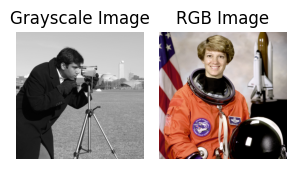

In [108]:
image_gray = data.camera()
image_rgb = data.astronaut()

fig, axes = plt.subplots(1, 2, figsize=(3, 3))

axes[0].imshow(image_gray, cmap="gray")
axes[0].axis("off")
axes[0].set_title("Grayscale Image")

print ("Shape Img Grayscale :" , image_gray.shape)
print ("Shape Img RGB :" , image_rgb.shape)

axes[1].imshow(image_rgb)
axes[1].axis("off")
axes[1].set_title("RGB Image")

plt.tight_layout()
plt.show()

In [109]:
def apply_kernel_rgb(image, kernel):
    result = np.zeros_like(image)
    for c in range(3):
        result[:, :, c] = convolve2d(image[:, :, c], kernel, mode='same')
    return np.clip(result, 0, 255).astype(np.uint8)

Blur Result (Gray) ---- Blur Result (RGB)


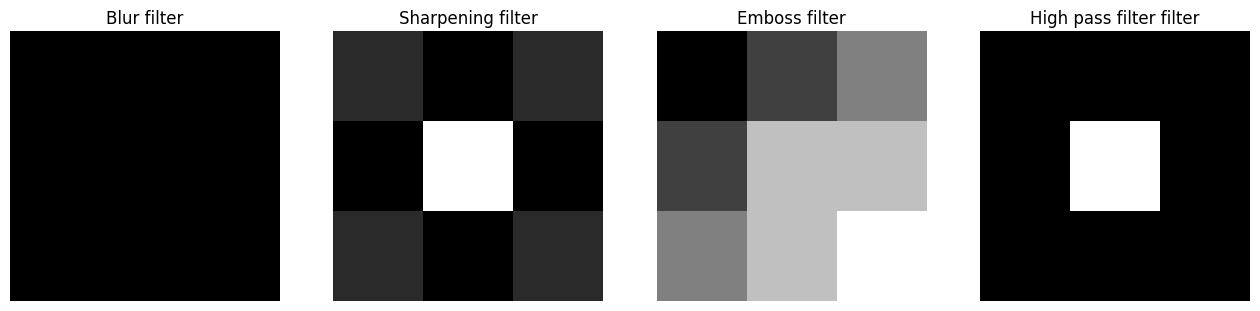

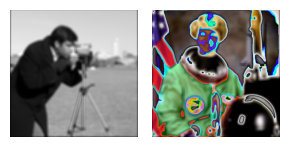

Sharpening Result (Gray) ---- Sharpening Result (RGB)


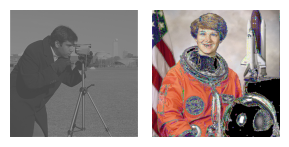

Emboss Result (Gray) ---- Emboss Result (RGB)


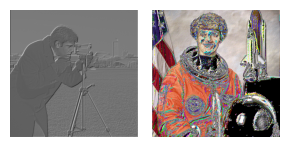

High pass filter Result (Gray) ---- High pass filter Result (RGB)


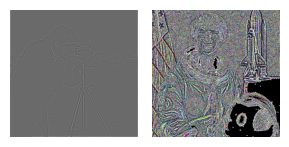

In [110]:
kernels = {
    'Blur': np.ones((13, 13)) / 100,  # Average kernel to blur the image
    'Sharpening': np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]]),
    'Emboss': np.array([[-2, -1, 0],
                        [-1, 1, 1],
                        [0, 1, 2]]),
    'High pass filter': np.array([[-1, -1, -1],  # Kernel rejecting low frequencies (uniform color areas)
                                   [-1, 8, -1],
                                   [-1, -1, -1]])
}

fig, axes = plt.subplots(1, len(kernels), figsize=(16, 4))
for ax, (name, kernel) in zip(axes, kernels.items()):
    ax.imshow(kernel, cmap='gray', interpolation='nearest')
    ax.set_title(f'{name} filter')
    ax.axis('off')

for name, kernel in kernels.items():
    result_gray = convolve2d(image_gray, kernel, mode='same')
    result_rgb = apply_kernel_rgb(image_rgb, kernel)
    
    fig, axes = plt.subplots(1, 2, figsize=(3, 3))
    
    axes[0].imshow(result_gray, cmap="gray")
    print(f"{name} Result (Gray) ---- {name} Result (RGB)")
    axes[0].axis("off")
    
    axes[1].imshow(result_rgb)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()